# Type Ia Supernova Monitor

## Overview

This notebook implements a multi-broker alert aggregation pipeline for discovering and monitoring Type Ia supernovae (SNe Ia) in the **Rubin Observatory LSST Deep Drilling Fields (DDFs)** and other targeted fields. It queries three independent data sources, cross-matches detections, and produces a ranked list of SN Ia candidates with classification probabilities, light curves, and quality diagnostics.

### Data Sources

| Broker           | Survey      | Coverage                         | Classifier                  | P(Ia) Range |
| ---------------- | ----------- | -------------------------------- | --------------------------- | ----------- |
| **ANTARES**      | ZTF + Rubin | Dec > -30 (ZTF), all-sky (Rubin) | Heuristic proxy             | 0.05 - 0.50 |
| **ALeRCE** (ZTF) | ZTF         | Dec > -30                        | `stamp_classifier` ML       | 0.0 - 1.0   |
| **ALeRCE-LSST**  | Rubin/LSST  | All DDFs                         | `stamp_classifier_rubin` ML | 0.0 - 1.0   |

### Pipeline Steps

1. **Query** each broker for transient/SN candidates in the target fields
2. **Cross-match** detections across brokers by sky coordinates (1 arcsec tolerance) and shared object IDs
3. **Deduplicate** into unique astrophysical objects, merging broker-specific metadata
4. **Classify** using per-broker P(Ia) probabilities and compute aggregate statistics
5. **Filter** by probability threshold, broker agreement, and quality cuts
6. **Screen** against known variable star catalogs to remove contaminants
7. **Report** a consolidated table with IDs, coordinates, classifications, and diagnostics
8. **Inspect** individual candidates: light curves, postage stamps, and detailed classifications

### Target Fields

The pipeline searches the Rubin DDFs plus additional targeted fields, each with a 1.75-degree search radius:

| Field    | RA (deg) | Dec (deg) | Notes                                  |
| -------- | -------- | --------- | -------------------------------------- |
| COSMOS   | 150.11   | +2.23     | Also in ZTF footprint                  |
| XMM-LSS  | 35.57    | -4.82     | Also in ZTF footprint                  |
| ECDFS    | 52.98    | -28.12    | Near ZTF limit                         |
| ELAIS-S1 | 9.45     | -44.02    | Southern, no ZTF                       |
| EDFS_a   | 58.90    | -49.32    | Southern, no ZTF                       |
| EDFS_b   | 63.60    | -47.60    | Southern, no ZTF                       |
| M49      | 187.44   | +8.00     | NGC 4472, Virgo Cluster; ZTF footprint |

**Key limitation:** ZTF cannot observe below Dec ~ -30, so the three southern DDFs (ELAIS-S1, EDFS_a, EDFS_b) are only covered by the ALeRCE-LSST broker and ANTARES (when it has Rubin data). M49 and the northern DDFs (COSMOS, XMM-LSS) have full ZTF coverage from both ANTARES and ALeRCE.


In [1]:
# ========================= PARAMETERS =========================
MIN_IA_PROBABILITY = 0.3  # Min Type Ia probability (0-1)
DAYS_BACK = 5  # How many days back to search
MAX_ALERTS = 1000  # Max alerts per broker
REQUIRE_RUBIN = True  # Only keep ANTARES loci with Rubin/LSST data
FILTER_ELLIPTICAL = False  # Filter for elliptical host galaxies
MIN_BROKERS = 1  # Min brokers detecting object (1 or 2)
MIN_AGREEMENT = 0.0  # Min agreement score (0.0 = disabled)
ATLAS_ENRICHMENT = True  # Fetch ATLAS forced photometry for candidates
CACHE_DIR = "./cache/data"

# --- New feature toggles ---
USE_ALERCE_DB = True  # Direct PostgreSQL access to ALeRCE (faster bulk queries)
APPLY_EXTINCTION = True  # Galactic dust extinction corrections (IRSA SFD maps)
QUERY_NED = True  # NED spectroscopic redshift lookups for host galaxies

# Fields to search (default: all 7 — the 6 Rubin DDFs + M49)
# Set to a subset to restrict, e.g.:
#   DDF_SELECTION = [f for f in DDF_FIELDS if f['name'] in ['COSMOS', 'M49']]
DDF_SELECTION = None  # None = all fields
# ==============================================================

## Configuration Parameters

The cell above controls the pipeline behavior. Here is what each parameter does:

### Classification Threshold

- **`MIN_IA_PROBABILITY`** — Minimum mean P(Ia) to keep a candidate. This is the most important filter.
  - `0.3`: Permissive — includes ANTARES heuristic detections (proxy capped at 0.50) and moderate ALeRCE classifications. Good for initial exploration.
  - `0.5`: Moderate — requires at least one strong ML classification (ALeRCE) or multi-broker agreement.
  - `0.8`: Strict — only keeps objects with high-confidence ALeRCE ML classifications. ANTARES-only detections will never pass this threshold (proxy max = 0.50).

### Search Parameters

- **`DAYS_BACK`** — How many days back from today to search for new alerts. Only affects ANTARES; ALeRCE queries are not time-filtered.
- **`MAX_ALERTS`** — Maximum number of alerts to retrieve per broker.
- **`REQUIRE_RUBIN`** — If `True`, ANTARES objects without any Rubin/LSST detections are dropped.

### Multi-Broker Filters

- **`MIN_BROKERS`** — Minimum number of brokers that must independently detect an object.
- **`MIN_AGREEMENT`** — Minimum agreement score between brokers' P(Ia) values. 0.0 disables this filter.

### New Feature Toggles

- **`USE_ALERCE_DB`** — If `True`, use direct PostgreSQL access to ALeRCE's ZTF database for bulk queries (requires `psycopg2-binary`). Falls back to REST API if unavailable.
- **`APPLY_EXTINCTION`** — If `True`, query IRSA SFD dust maps for galactic extinction at each candidate's RA/Dec. Adds `A_u`, `A_g`, `A_r`, `A_i`, `A_z` columns and enables extinction-corrected peak magnitudes.
- **`QUERY_NED`** — If `True`, query NED for spectroscopic host galaxy redshifts (18 arcsec search radius). Adds `ned_redshift`, `ned_distmod`, `ned_name` columns. Enables absolute magnitude estimation when combined with peak fitting.

### Optional Enrichment

- **`FILTER_ELLIPTICAL`** — If `True`, cross-match with galaxy catalogs and prefer candidates near elliptical hosts. Note: PS1/SDSS coverage is limited for southern DDFs.
- **`ATLAS_ENRICHMENT`** — If `True`, fetch ATLAS forced photometry for each candidate.

### Field Selection

- **`DDF_SELECTION`** — Which fields to search. `None` means all 7 (the 6 Rubin DDFs + M49).


In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('supernova_monitor.ipynb'))))

import warnings; warnings.filterwarnings('ignore')
import logging, pandas as pd, numpy as np
from datetime import datetime
from IPython.display import display, HTML

%matplotlib inline
import matplotlib; matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO)

from supernova_monitor import SupernovaMonitor
from core.ddf_fields import DDF_FIELDS
from utils.plotting import PlottingUtils

monitor = SupernovaMonitor(
    cache_dir=CACHE_DIR,
    use_alerce_db=USE_ALERCE_DB,
    apply_extinction=APPLY_EXTINCTION,
    query_ned=QUERY_NED,
)
print(f"Active brokers: {', '.join(monitor.brokers.keys())}")
if monitor.variable_screener.variables_df is not None:
    print(f"Known variables loaded: {len(monitor.variable_screener.variables_df)}")
print(f"ATLAS available: {monitor.atlas_client.available}")
print(f"ALeRCE DB: {USE_ALERCE_DB}  |  Extinction: {APPLY_EXTINCTION}  |  NED redshifts: {QUERY_NED}")
if 'ALeRCE-LSST' in monitor.brokers:
    print(f"ALeRCE-LSST: Rubin survey data enabled")

INFO:cache.alert_cache:Initialized cache database at ./cache/data/alerts_cache.db
INFO:cache.alert_cache:Initialized cache database at ./cache/data/alerts_cache.db
INFO:cache.alert_cache:Initialized cache database at ./cache/data/alerts_cache.db
INFO:core.variable_screen:Loaded 1937 variables from COSMOS_variables.csv
INFO:core.variable_screen:Loaded 1587 variables from XMM-LSS_variables.csv
INFO:core.variable_screen:Loaded 3216 variables from ECDFS_variables.csv
INFO:core.variable_screen:Loaded 3120 variables from ELAIS-S1_variables.csv
INFO:core.variable_screen:Loaded 1893 variables from EDFS_a_variables.csv
INFO:core.variable_screen:Loaded 1996 variables from EDFS_b_variables.csv
INFO:core.variable_screen:Loaded 13749 known variables total
INFO:supernova_monitor:Fink LSST client initialized (API reachable)
INFO:broker_clients.antares_client:Patched antares_client cone_search for astropy 7.x compatibility
INFO:broker_clients.antares_client:ANTARES client initialized successfully
INFO

Active brokers: ANTARES, ALeRCE, ALeRCE-LSST
Known variables loaded: 13749
ATLAS available: False
ALeRCE DB: True  |  Extinction: True  |  NED redshifts: True
ALeRCE-LSST: Rubin survey data enabled


## Environment Setup

The cell above initializes the `SupernovaMonitor` object, which:

1. Creates three broker clients:

   - **ANTARES** — queries the ANTARES broker via its REST API for loci with supernova-related tags in/near the DDFs. ANTARES ingests both ZTF and (limited) Rubin alert streams.
   - **ALeRCE** (ZTF) — queries ALeRCE's stamp classifier for objects classified as SN Ia with the ZTF survey.
   - **ALeRCE-LSST** — queries ALeRCE's `stamp_classifier_rubin` for objects classified as SN using Rubin/LSST data. This is the primary source of multi-epoch Rubin photometry.

2. Loads the **known variable star screener** (Gaia DR3 + VSX catalogs) to flag and optionally remove known variables that masquerade as transients.

3. Initializes the **ATLAS forced photometry client** (if `ATLAS_ENRICHMENT` is enabled) for independent optical light curve validation.

4. Sets up the **alert cache** (SQLite database in `CACHE_DIR`) to avoid redundant API calls on re-runs.


In [5]:
# === Run this cell ONCE after code changes to clear stale caches ===
# After running, comment out or skip this cell on subsequent runs.

import glob, os

CLEAR_CACHE = False  # Set to False after first run

if CLEAR_CACHE:
    cache_files = glob.glob(os.path.join(CACHE_DIR, "*.json"))
    db_files = glob.glob(os.path.join(CACHE_DIR, "*.db"))
    removed = 0
    for f in cache_files + db_files:
        os.remove(f)
        removed += 1
    if removed:
        print(f"Cleared {removed} stale cache files from {CACHE_DIR}")
        # Re-initialize cache DB
        monitor.cache = __import__(
            "cache.alert_cache", fromlist=["AlertCache"]
        ).AlertCache(CACHE_DIR)
    else:
        print("No cache files to clear")
else:
    print("Cache clearing skipped (CLEAR_CACHE=False)")

INFO:cache.alert_cache:Initialized cache database at ./cache/data/alerts_cache.db


Cleared 2 stale cache files from ./cache/data


## Cache Management

The pipeline caches API responses locally to avoid redundant network calls. After modifying broker client code (e.g., changing query parameters, updating survey support), you should clear the cache once to ensure fresh data is fetched. Set `CLEAR_CACHE = True` in the cell below, run it, then set it back to `False` for subsequent runs.

Cache files are stored in `CACHE_DIR` (default: `./cache/data/`) as JSON files and a SQLite database (`alerts_cache.db`).


In [6]:
results = monitor.run_full_pipeline(
    min_ia_probability=MIN_IA_PROBABILITY,
    days_back=DAYS_BACK,
    limit=MAX_ALERTS,
    require_rubin=REQUIRE_RUBIN,
    filter_elliptical=FILTER_ELLIPTICAL,
    min_agreement=MIN_AGREEMENT,
    min_brokers=MIN_BROKERS,
    ddf_fields=DDF_SELECTION,
    atlas_enrichment=ATLAS_ENRICHMENT,
)

if results is not None and len(results) > 0:
    candidates = results
    print(f"Found {len(candidates)} candidates with P(Ia) >= {MIN_IA_PROBABILITY}")
    if "mean_ia_prob" in candidates.columns:
        v = candidates["mean_ia_prob"].dropna()
        if len(v) > 0:
            print(f"  P(Ia): mean={v.mean():.3f}  min={v.min():.3f}  max={v.max():.3f}")
    if "num_brokers" in candidates.columns:
        for n, cnt in candidates["num_brokers"].value_counts().sort_index().items():
            print(f"  {n} broker(s): {cnt} objects")
    if "ddf_field" in candidates.columns:
        print("\nBy DDF field:")
        for field, cnt in candidates["ddf_field"].value_counts().sort_index().items():
            if field:
                print(f"  {field}: {cnt}")

    # New feature coverage
    if "A_g" in candidates.columns:
        n_ext = candidates["A_g"].notna().sum()
        print(f"\nExtinction: {n_ext}/{len(candidates)} have A_g values")
        if n_ext > 0:
            print(
                f"  A_g range: {candidates['A_g'].min():.4f} - {candidates['A_g'].max():.4f}"
            )
    if "ned_redshift" in candidates.columns:
        n_z = candidates["ned_redshift"].notna().sum()
        print(f"NED redshift: {n_z}/{len(candidates)} have spectroscopic z")
        if n_z > 0:
            z_vals = candidates["ned_redshift"].dropna()
            print(f"  z range: {z_vals.min():.4f} - {z_vals.max():.4f}")
    if "atlas_has_data" in candidates.columns:
        n_atlas = candidates["atlas_has_data"].sum()
        print(f"ATLAS data: {n_atlas}/{len(candidates)} candidates")
else:
    candidates = None
    print(f"No candidates found with P(Ia) >= {MIN_IA_PROBABILITY}.")
    merged = getattr(monitor, "_last_merged_alerts", None)
    if merged is not None and len(merged) > 0 and "mean_ia_prob" in merged.columns:
        v = merged["mean_ia_prob"].dropna()
        n_vars = (
            merged["known_variable"].sum() if "known_variable" in merged.columns else 0
        )
        print(
            f"\nPre-filter distribution ({len(merged)} objects, {n_vars} known variables removed):"
        )
        print(f"  P(Ia): mean={v.mean():.3f}  min={v.min():.3f}  max={v.max():.3f}")
        for thresh in [0.3, 0.5, 0.7, 0.8, 0.9]:
            n = (v >= thresh).sum()
            print(f"  P(Ia) >= {thresh}: {n} objects")
        print(f"\nAdjust MIN_IA_PROBABILITY in the parameters cell and re-run.")
    elif REQUIRE_RUBIN:
        print("Try REQUIRE_RUBIN=False to include ZTF-only objects.")

INFO:supernova_monitor:============================================================
INFO:supernova_monitor:Starting SuperNova Monitoring Pipeline
INFO:supernova_monitor:Time: 2026-03-12T18:13:28.258390
INFO:supernova_monitor:DDFs: COSMOS, XMM-LSS, ECDFS, ELAIS-S1, EDFS_a, EDFS_b, M49
INFO:supernova_monitor:Parameters: P(Ia) >= 0.3, days_back=5, limit=1000, require_rubin=True, elliptical_filter=False, atlas_enrichment=True
INFO:supernova_monitor:Features: extinction=True, alerce_db=True, ned_redshifts=True, rsp_photometry=False
INFO:supernova_monitor:============================================================
INFO:supernova_monitor:Querying 3 brokers for SN Ia candidates
INFO:supernova_monitor:Querying ANTARES...
INFO:broker_clients.antares_client:  Searching DDF COSMOS (RA=150.11, Dec=2.23, r=1.75 deg)
INFO:broker_clients.antares_client:    COSMOS: checked 200 loci, accepted 83 so far...
INFO:broker_clients.antares_client:    COSMOS: checked 262, accepted 142
INFO:broker_clients.antar

Found 605 candidates with P(Ia) >= 0.3
  P(Ia): mean=0.301  min=0.300  max=0.450
  1 broker(s): 605 objects

By DDF field:
  COSMOS: 130
  ECDFS: 125
  EDFS_a: 75
  EDFS_b: 66
  ELAIS-S1: 136
  M49: 73

Extinction: 605/605 have A_g values
  A_g range: 0.0160 - 0.2900
NED redshift: 131/605 have spectroscopic z
  z range: -0.0003 - 4.9067


## Run the Full Pipeline

The cell below executes the complete pipeline. Here is what happens at each stage:

### 1. Broker Queries

Each broker is queried for all 7 fields (or the subset specified in `DDF_SELECTION`):

- **ANTARES**: Cone search per field for loci tagged with supernova-related tags (`superphot_plus_classified`, `SN_candies`, `high_amplitude_transient_candidate`). Returns objects with ZTF photometry and, if available, a single Rubin detection per locus. If `REQUIRE_RUBIN=True`, loci without any Rubin data are dropped.

- **ALeRCE (ZTF)**: Queries for objects classified as SN Ia by the `stamp_classifier` in ZTF data. Returns ML classification probabilities (P(Ia), P(II), P(Ib/c), P(SLSN)) from the trained random-forest model. Only covers fields with Dec > -30 (COSMOS, XMM-LSS, M49, and marginally ECDFS).

- **ALeRCE-LSST**: Queries globally for all objects classified as SN by `stamp_classifier_rubin`, then filters locally to the field footprints. This works around a known limitation where ALeRCE's LSST cone search returns empty results. Returns P(SN) probabilities but does not sub-classify SN types. Covers all fields.

### 2. Cross-Matching and Deduplication

Objects from different brokers that refer to the same astrophysical source are merged:

- **Coordinate matching**: Objects within 1 arcsec are considered the same source
- **ID matching**: Objects sharing a ZTF `object_id` or `ztf_object_id` are also merged
- Each unique source retains broker-specific IDs, classification probabilities, and metadata

### 3. Classification Aggregation

For each unique object:

- **`mean_ia_prob`**: Mean of all broker P(Ia) / P(SN) values
- **`std_ia_prob`**: Standard deviation (0 if only one broker)
- **`agreement_score`**: 1.0 if std < 0.1, 0.5 if std < 0.25, 0.0 otherwise

### 4. Filtering

Objects are filtered by:

1. `MIN_IA_PROBABILITY` threshold on `mean_ia_prob`
2. `MIN_AGREEMENT` threshold on `agreement_score`
3. `MIN_BROKERS` threshold on `num_brokers`
4. Known variable star screening (Gaia DR3 + VSX catalog cross-match)

### 5. Understanding the P(Ia) Values

**Important caveats about classification probabilities:**

- **ANTARES proxy P(Ia)** is a simple heuristic based on star/galaxy score and duration, _not_ a trained ML classifier. It is capped at 0.50 by design so that ANTARES detections alone cannot dominate the pipeline. A P(Ia) of 0.30 from ANTARES means "plausible transient in a galaxy-like host" — not a confident SN Ia classification.

- **ALeRCE ZTF P(Ia)** comes from a random-forest stamp classifier trained on labeled ZTF data. Values > 0.7 are generally reliable. This classifier also provides P(II), P(Ib/c), and P(SLSN) for SN subtype discrimination.

- **ALeRCE-LSST P(SN)** comes from `stamp_classifier_rubin` which classifies into SN / AGN / VS (variable star) / asteroid / bogus. A high P(SN) means "this is likely a supernova" but provides no Ia vs. II vs. Ib/c subtyping. The P(SN) value is stored in the `sn_ia_prob` column for consistency with the pipeline's filtering logic.

If no candidates pass the filter, the cell prints the pre-filter probability distribution and suggests adjusting `MIN_IA_PROBABILITY`.


## Consolidated Broker Report

The table below shows all candidates that passed the pipeline filters. Here is how to read each column:

### Identification Columns

- **DDF** — Which Deep Drilling Field this object is in
- **Rubin DIA ID** — The Rubin Data Management Difference Image Analysis (DIA) object identifier.
- **ANTARES ID / ALeRCE ID / ALeRCE-LSST ID** — Broker-specific object identifiers.

### Classification Columns

- **ANTARES P(Ia)** — Heuristic proxy probability (0.05–0.50). Not an ML classification.
- **ALeRCE P(Ia)** — ML stamp classifier probability from ZTF data.
- **ALeRCE-LSST P(SN)** — ML stamp classifier probability from Rubin data. P(supernova), not P(Type Ia).
- **Mean P(Ia)** — Average of all available broker probabilities for this object.
- **Agreement** — How well brokers agree: 1.0 (high), 0.5 (moderate), 0.0 (low).

### Galactic Extinction

- **A_g / A_r** — SFD galactic extinction in g and r bands (magnitudes). From IRSA dust maps queried at each object's RA/Dec. Used to compute extinction-corrected peak magnitudes.

### Host Galaxy Redshift

- **z (NED)** — Spectroscopic redshift of the nearest NED source within 18 arcsec.
- **DM (NED)** — Distance modulus from the NED redshift (WMAP7 cosmology). Used with extinction-corrected peak mag to estimate absolute magnitude.
- **NED Host** — Name of the matched NED source (truncated to 25 chars).

### Quality Diagnostics

- **SG score** — Star/galaxy score from ZTF (0 = galaxy, 1 = star).
- **Duration (d)** — Time span between first and last detection in days.
- **RB score** — ZTF real/bogus score (0 = bogus, 1 = real).
- **Known Var** — Flagged as `YES` if matching a known variable star.
- **ATLAS** — Number of ATLAS forced photometry points in cyan (c) and orange (o) bands.


In [7]:
if candidates is not None and len(candidates) > 0:
    rows = []
    for idx, r in candidates.iterrows():
        rubin_id = r.get("rubin_dia_object_id", "")
        if not rubin_id or (isinstance(rubin_id, float) and pd.isna(rubin_id)):
            rubin_id = "--"

        e = {
            "DDF": r.get("ddf_field", "--"),
            "Rubin DIA ID": rubin_id,
            "ANTARES ID": r.get("object_id_ANTARES", "--"),
            "ALeRCE ID": r.get("object_id_ALeRCE", "--"),
            "ALeRCE-LSST ID": r.get("object_id_ALeRCE-LSST", "--"),
            "RA": r.get("ra"),
            "Dec": r.get("dec"),
            "Discovery": r.get("discovery_date", "--"),
            "Brokers": r.get("brokers_detected", "--"),
        }

        # Per-broker P(Ia) / P(SN)
        for bk in ["ANTARES", "ALeRCE", "ALeRCE-LSST"]:
            val = r.get(f"classification_{bk}_ia_prob")
            label = "P(SN)" if bk == "ALeRCE-LSST" else "P(Ia)"
            e[f"{bk} {label}"] = f"{val:.3f}" if pd.notna(val) else "--"

        # ALeRCE ZTF extra SN types
        for sn, lab in [("ii", "II"), ("ibc", "Ib/c"), ("slsn", "SLSN")]:
            val = r.get(f"classification_ALeRCE_{sn}_prob")
            e[f"ALeRCE P({lab})"] = f"{val:.3f}" if pd.notna(val) else "--"

        # Combined stats
        mp = r.get("mean_ia_prob")
        e["Mean P(Ia)"] = f"{mp:.3f}" if pd.notna(mp) else "--"
        ag = r.get("agreement_score")
        e["Agreement"] = f"{ag:.2f}" if pd.notna(ag) else "--"

        # Galactic extinction
        a_g = r.get("A_g")
        a_r = r.get("A_r")
        e["A_g"] = f"{a_g:.3f}" if pd.notna(a_g) else "--"
        e["A_r"] = f"{a_r:.3f}" if pd.notna(a_r) else "--"

        # NED redshift
        ned_z = r.get("ned_redshift")
        ned_dm = r.get("ned_distmod")
        ned_name = r.get("ned_name", "")
        e["z (NED)"] = f"{ned_z:.4f}" if pd.notna(ned_z) else "--"
        e["DM (NED)"] = f"{ned_dm:.2f}" if pd.notna(ned_dm) else "--"
        e["NED Host"] = str(ned_name)[:25] if pd.notna(ned_name) and ned_name else "--"

        # Quality diagnostics
        sg = r.get("sgscore_ANTARES")
        e["SG score"] = f"{sg:.2f}" if pd.notna(sg) else "--"
        dur = r.get("duration_ANTARES")
        e["Duration (d)"] = f"{dur:.0f}" if pd.notna(dur) else "--"
        rb = r.get("rb_score_ANTARES")
        e["RB score"] = f"{rb:.2f}" if pd.notna(rb) else "--"

        # Variable screening
        e["Known Var"] = "YES" if r.get("known_variable") else "--"

        # ATLAS enrichment
        if "atlas_has_data" in r.index:
            n_c = r.get("atlas_n_cyan", 0)
            n_o = r.get("atlas_n_orange", 0)
            e["ATLAS"] = f"c={n_c} o={n_o}" if r.get("atlas_has_data") else "--"

        # Magnitudes
        for bk in ["ANTARES", "ALeRCE"]:
            mag = r.get(f"magnitude_{bk}")
            e[f"Mag ({bk[:3]})"] = f"{mag:.2f}" if pd.notna(mag) else "--"

        rows.append(e)

    report = pd.DataFrame(rows).fillna("--")
    print(f"Consolidated Broker Report: {len(report)} events\n")
    pd.set_option("display.max_rows", None)
    display(
        report.style.set_properties(
            **{"text-align": "center", "font-size": "11px"}
        ).set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [("text-align", "center"), ("font-size", "11px")],
                }
            ]
        )
    )
    pd.reset_option("display.max_rows")
else:
    print("No candidates for report")

Consolidated Broker Report: 605 events



In [8]:
# Generate ALeRCE LSST Explorer links for all candidates with LSST IDs
# (Based on ALeRCE reference notebooks in usecases/notebooks/LSST/)

if candidates is not None and len(candidates) > 0:
    lsst_ids = candidates["object_id_ALeRCE-LSST"].dropna().astype(str).tolist()
    lsst_ids = [x for x in lsst_ids if x != "nan" and x != ""]

    if lsst_ids:
        # Individual object links (first 10)
        print(f"ALeRCE LSST Explorer links ({len(lsst_ids)} objects with LSST IDs):\n")
        for oid in lsst_ids[:10]:
            url = f"https://lsst.alerce.online/object/{oid}?survey=lsst"
            display(HTML(f'  <a href="{url}" target="_blank">{oid}</a>'))

        if len(lsst_ids) > 10:
            print(f"\n  ... and {len(lsst_ids) - 10} more")

        # Batch link (up to 200 objects — ALeRCE Explorer limit)
        batch = lsst_ids[:200]
        batch_url = (
            "https://lsst.alerce.online/?oid=" + ",".join(batch) + "&survey=lsst"
        )
        print(f"\nBatch view ({min(len(lsst_ids), 200)} objects):")
        display(
            HTML(
                f'<a href="{batch_url}" target="_blank">Open in ALeRCE LSST Explorer</a>'
            )
        )
    else:
        print("No candidates have ALeRCE-LSST IDs")
else:
    print("No candidates available")

KeyError: 'object_id_ALeRCE-LSST'

## Pipeline Diagnostics: Extinction, Redshifts, and Host Properties

Summary plots for the new pipeline features. These only appear if the corresponding
features are enabled (`APPLY_EXTINCTION`, `QUERY_NED`).


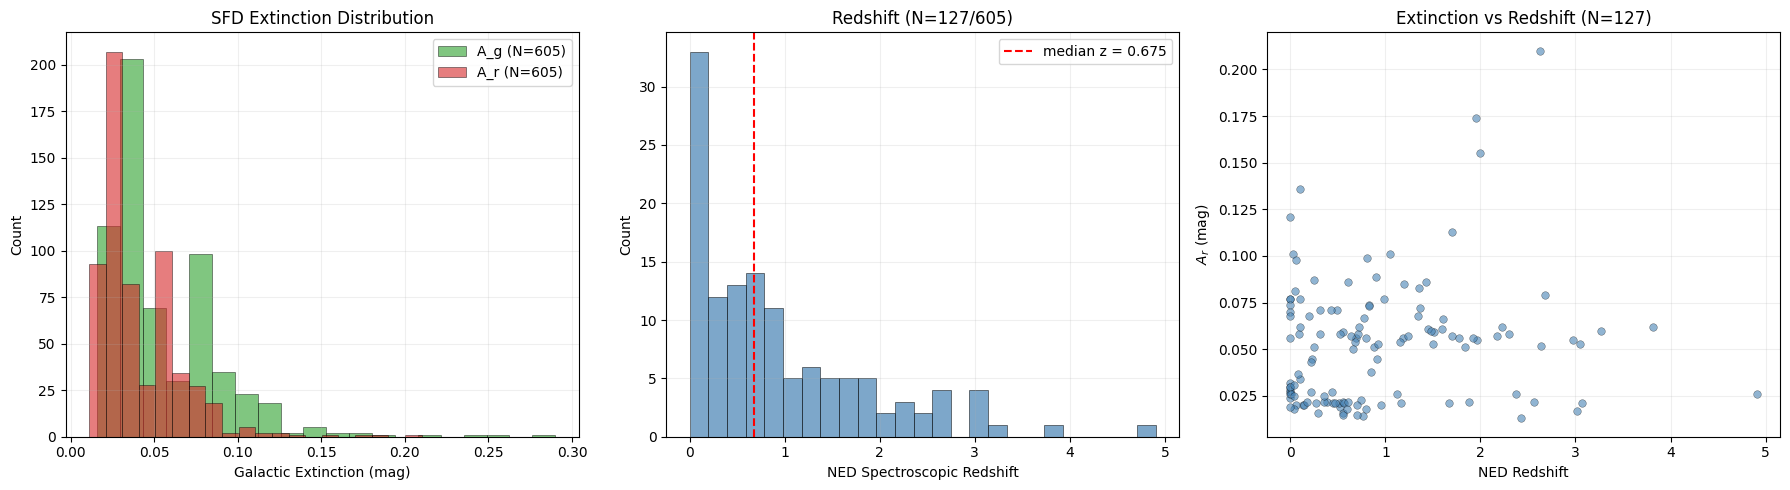

In [9]:
if candidates is not None and len(candidates) > 0:
    n_panels = 0
    has_ext = "A_g" in candidates.columns and candidates["A_g"].notna().any()
    has_z = (
        "ned_redshift" in candidates.columns
        and candidates["ned_redshift"].notna().any()
    )
    n_panels = int(has_ext) + int(has_z) + int(has_ext and has_z)

    if n_panels > 0:
        fig, axes = plt.subplots(1, min(n_panels, 3), figsize=(6 * min(n_panels, 3), 5))
        if n_panels == 1:
            axes = [axes]
        panel = 0

        # Panel: Extinction distribution
        if has_ext:
            ax = axes[panel]
            panel += 1
            for band, color in [("A_g", "#2ca02c"), ("A_r", "#d62728")]:
                vals = candidates[band].dropna()
                ax.hist(
                    vals,
                    bins=20,
                    alpha=0.6,
                    color=color,
                    edgecolor="k",
                    linewidth=0.5,
                    label=f"{band} (N={len(vals)})",
                )
            ax.set_xlabel("Galactic Extinction (mag)")
            ax.set_ylabel("Count")
            ax.set_title("SFD Extinction Distribution")
            ax.legend()
            ax.grid(True, alpha=0.2)

        # Panel: Redshift distribution
        if has_z:
            ax = axes[panel]
            panel += 1
            z_valid = candidates["ned_redshift"].dropna()
            z_valid = z_valid[z_valid > 0]
            if len(z_valid) > 0:
                ax.hist(
                    z_valid,
                    bins=25,
                    alpha=0.7,
                    color="steelblue",
                    edgecolor="k",
                    linewidth=0.5,
                )
                ax.axvline(
                    z_valid.median(),
                    color="red",
                    linestyle="--",
                    label=f"median z = {z_valid.median():.3f}",
                )
                ax.set_xlabel("NED Spectroscopic Redshift")
                ax.set_ylabel("Count")
                n_total = len(candidates)
                ax.set_title(f"Redshift (N={len(z_valid)}/{n_total})")
                ax.legend()
                ax.grid(True, alpha=0.2)

        # Panel: Extinction vs redshift
        if has_ext and has_z:
            ax = axes[panel]
            panel += 1
            mask = candidates["A_r"].notna() & candidates["ned_redshift"].notna()
            mask = mask & (candidates["ned_redshift"] > 0)
            sub = candidates[mask]
            if len(sub) > 0:
                ax.scatter(
                    sub["ned_redshift"],
                    sub["A_r"],
                    s=30,
                    alpha=0.6,
                    c="steelblue",
                    edgecolors="k",
                    linewidth=0.3,
                )
                ax.set_xlabel("NED Redshift")
                ax.set_ylabel("$A_r$ (mag)")
                ax.set_title(f"Extinction vs Redshift (N={len(sub)})")
                ax.grid(True, alpha=0.2)

        plt.tight_layout()
        plt.show()
    else:
        print("No extinction or redshift data to plot.")
else:
    print("No candidates available for diagnostics.")

## Inspect a Single Candidate

Use the cell below to examine an individual candidate in detail. Set `SELECTED_INDEX` to the row number (0-based) from the report table above.

The inspection shows:

- **Object IDs** across all brokers and the Rubin DIA ID
- **Sky coordinates** (RA, Dec in degrees, J2000)
- **Per-broker classification table** showing all available class probabilities:
  - For ANTARES/ALeRCE-ZTF: P(Ia), P(II), P(Ib/c), P(SLSN)
  - For ALeRCE-LSST: P(SN), P(AGN), P(VS), P(ASTEROID), P(BOGUS) — the five classes of the Rubin stamp classifier
- **ANTARES tags** indicating which processing pipelines flagged this object


In [10]:
SELECTED_INDEX = 100

if candidates is not None and len(candidates) > 0:
    c = candidates.iloc[SELECTED_INDEX]
    oid = (
        c.get("object_id_ALeRCE-LSST")
        or c.get("object_id_ANTARES")
        or c.get("object_id_ALeRCE")
        or "?"
    )
    rubin_id = c.get("rubin_dia_object_id", "")

    print(f"Candidate {SELECTED_INDEX}/{len(candidates)-1}: {oid}")
    if rubin_id:
        print(f"  Rubin DIA ID: {rubin_id}")
    print(f"  RA, Dec:  {c['ra']:.5f}, {c['dec']:.5f}")
    prob = c.get("mean_ia_prob")
    print(f"  P(Ia):    {prob:.3f}" if pd.notna(prob) else "  P(Ia):    N/A")
    print(f"  Brokers:  {c.get('brokers_detected', 'N/A')}")

    # Per-broker classification table
    broker_names = c.get("broker_names", [])
    if isinstance(broker_names, str):
        broker_names = [b.strip() for b in broker_names.split(",")]
    tbl = []
    for bk in broker_names:
        row = {"Broker": bk}
        if bk == "ALeRCE-LSST":
            # LSST stamp classifier: SN/AGN/VS/asteroid/bogus
            for cls in ["sn", "agn", "vs", "asteroid", "bogus"]:
                col = (
                    f"classification_{bk}_{cls}_prob"
                    if cls != "sn"
                    else f"classification_{bk}_ia_prob"
                )
                row[f"P({cls.upper()})"] = (
                    f"{float(c[col]):.3f}"
                    if col in c.index and pd.notna(c[col])
                    else "--"
                )
        else:
            for sn in ["ia", "ii", "ibc", "slsn"]:
                col = f"classification_{bk}_{sn}_prob"
                row[f"P({sn.upper()})"] = (
                    f"{float(c[col]):.3f}"
                    if col in c.index and pd.notna(c[col])
                    else "--"
                )
        tbl.append(row)
    if tbl:
        print()
        display(pd.DataFrame(tbl).fillna("--"))

    tags = c.get("tags_ANTARES")
    if tags:
        print(f"  ANTARES tags: {tags}")
else:
    print("No candidates available")

Candidate 100/604: ANT2026xri1ybg188km
  Rubin DIA ID: 170028512753746123
  RA, Dec:  148.83271, 2.46054
  P(Ia):    0.300
  Brokers:  ANTARES



,Broker,P(IA),P(II),P(IBC),P(SLSN)
0,ANTARES,0.300,--,--,--


  ANTARES tags: in_LSSTDDF


INFO:broker_clients.antares_client:Retrieving light curve for ANTARES object ANT2026xri1ybg188km


Fetching light curve for ANT2026xri1ybg188km from ANTARES...


INFO:broker_clients.antares_client:Raw lightcurve: 120 rows, columns: ['time', 'alert_id', 'ant_mjd', 'ant_survey', 'ant_ra', 'ant_dec', 'ant_passband', 'ant_mag', 'ant_magerr', 'ant_maglim', 'ant_mag_corrected', 'ant_magerr_corrected', 'ant_magulim_corrected', 'ant_magllim_corrected']
INFO:broker_clients.antares_client:  Rubin: 120 rows
INFO:broker_clients.antares_client:Retrieved 120 photometric points for ANT2026xri1ybg188km



120 total photometric points
  Rubin: 120 pts
  band g: 120 pts


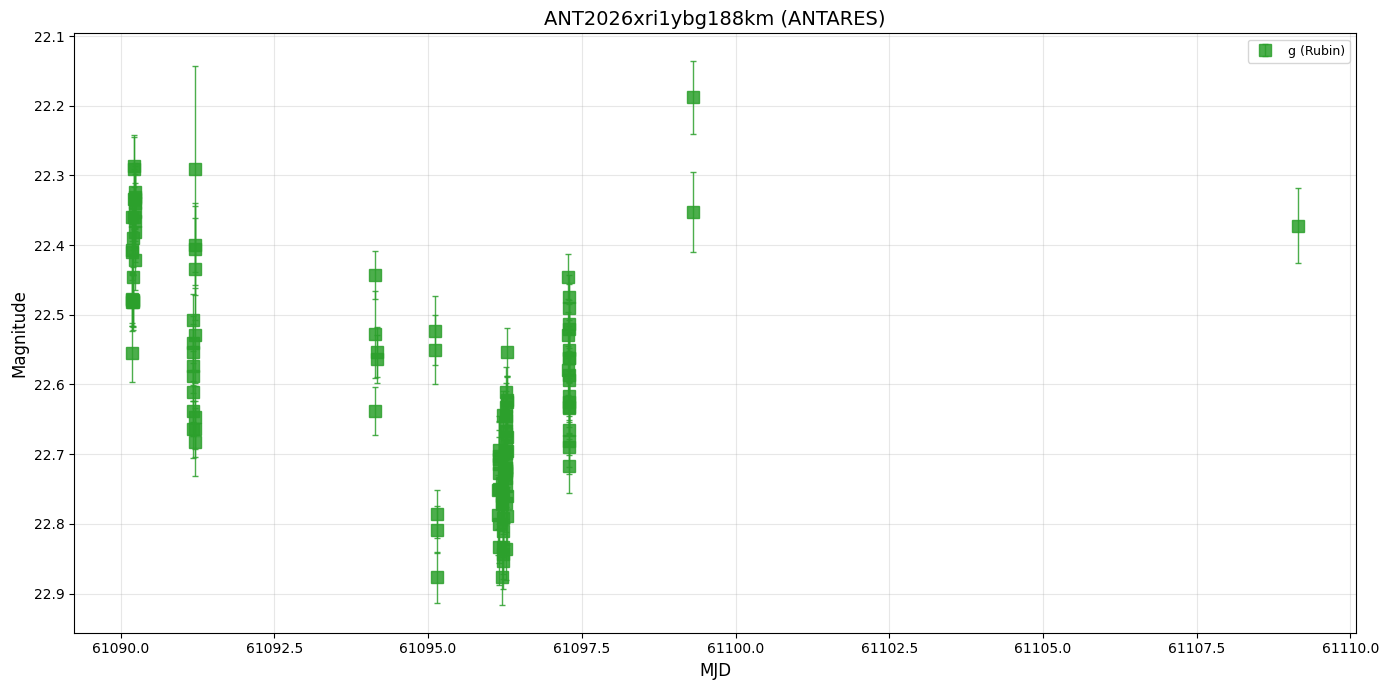


Photometry (first 20 rows — all epochs including negative flux):


,mjd,band,magnitude,mag_err,survey
0,61090.189137,g,22.359922,0.034851,Rubin
1,61090.189604,g,22.479029,0.037296,Rubin
2,61090.190066,g,22.477981,0.038784,Rubin
3,61090.190528,g,22.407153,0.035054,Rubin
4,61090.190993,g,22.554219,0.042107,Rubin
5,61090.191459,g,22.409443,0.040120,Rubin
6,61090.191924,g,22.481386,0.041250,Rubin
7,61090.192387,g,22.445701,0.038792,Rubin
8,61090.193787,g,22.389227,0.042250,Rubin
9,61090.194249,g,22.480118,0.037791,Rubin



Fetching stamps for ANT2026xri1ybg188km...
No stamps available


In [11]:
if candidates is not None and len(candidates) > 0:
    c = candidates.iloc[SELECTED_INDEX]

    # Resolve object ID and broker — prefer ALeRCE-LSST for Rubin photometry
    broker = None
    object_id = None
    for bk in ["ALeRCE-LSST", "ANTARES", "ALeRCE"]:
        oid_col = f"object_id_{bk}"
        if oid_col in c.index and pd.notna(c.get(oid_col)):
            broker = bk
            object_id = c[oid_col]
            break

    if broker is None or object_id is None:
        print("No object ID available for any broker")
        raise SystemExit

    print(f"Fetching light curve for {object_id} from {broker}...")

    lc = monitor.get_light_curve(object_id, broker=broker)

    # Also fetch ATLAS light curve and merge
    atlas_lc = None
    if monitor.atlas_client.available:
        print(
            f"Fetching ATLAS forced photometry for ({c['ra']:.5f}, {c['dec']:.5f})..."
        )
        atlas_lc = monitor.get_atlas_light_curve(c["ra"], c["dec"])
        if atlas_lc is not None:
            print(f"  ATLAS: {len(atlas_lc)} points")

    # If primary broker is not ALeRCE-LSST, also try to get LSST light curve
    if (
        broker != "ALeRCE-LSST"
        and "object_id_ALeRCE-LSST" in c.index
        and pd.notna(c.get("object_id_ALeRCE-LSST"))
    ):
        lsst_oid = c["object_id_ALeRCE-LSST"]
        print(f"Also fetching LSST light curve for {lsst_oid}...")
        lsst_lc = monitor.get_light_curve(lsst_oid, broker="ALeRCE-LSST")
        if lsst_lc is not None:
            print(f"  LSST: {len(lsst_lc)} points")
            lc = (
                pd.concat([lc, lsst_lc], ignore_index=True)
                if lc is not None
                else lsst_lc
            )

    # Combine broker + ATLAS light curves
    if lc is not None and atlas_lc is not None:
        lc = pd.concat([lc, atlas_lc], ignore_index=True)
    elif atlas_lc is not None:
        lc = atlas_lc

    if lc is not None and len(lc) > 0:
        n_total = len(lc)
        n_with_mag = lc["magnitude"].notna().sum() if "magnitude" in lc.columns else 0
        n_neg_flux = (lc["flux"] <= 0).sum() if "flux" in lc.columns else 0

        print(f"\n{n_total} total photometric points")
        if n_neg_flux > 0:
            print(f"  {n_with_mag} with positive flux (plottable in mag space)")
            print(f"  {n_neg_flux} with negative/zero flux (preserved in flux columns)")

        if "survey" in lc.columns:
            for s, n in lc["survey"].value_counts().items():
                print(f"  {s}: {n} pts")
        if "band" in lc.columns:
            for b, n in lc["band"].value_counts().items():
                print(f"  band {b}: {n} pts")
        if "source" in lc.columns:
            for s, n in lc["source"].value_counts().items():
                print(f"  {s}: {n} pts")

        # Magnitude-space plot (only positive-flux points)
        lc_prep = PlottingUtils.prepare_light_curve(lc)
        if lc_prep is not None and len(lc_prep) > 0:
            fig = PlottingUtils.plot_light_curve_matplotlib(
                lc_prep, title=f"{object_id} ({broker})"
            )
            plt.show()
            try:
                pfig = PlottingUtils.plot_light_curve_plotly(
                    lc_prep, title=f"{object_id} ({broker}) [Interactive]"
                )
                if pfig:
                    pfig.show()
            except:
                pass

        # Show raw data table (all rows including negative flux)
        print(f"\nPhotometry (first 20 rows — all epochs including negative flux):")
        cols_to_show = [
            c
            for c in [
                "mjd",
                "band",
                "flux",
                "flux_err",
                "magnitude",
                "mag_err",
                "science_flux",
                "survey",
                "source",
            ]
            if c in lc.columns
        ]
        display(lc[cols_to_show].head(20))
    else:
        print(f"No light curve data from {broker}")

    # Postage stamps
    print(f"\nFetching stamps for {object_id}...")
    try:
        stamps = monitor.get_stamps(object_id, c["ra"], c["dec"], broker=broker)
        if stamps:
            print(f"Stamp keys: {list(stamps.keys())}")
        else:
            print("No stamps available")
    except Exception as e:
        print(f"Stamps error: {e}")
else:
    print("No candidates available")

## LSST Alert Stamps (Science / Template / Difference)

For ALeRCE-LSST objects, the cell below retrieves and displays the Rubin alert image cutouts ("stamps") for the first three detections that triggered alerts. Each stamp shows three panels:

- **Science** — the direct image from the Rubin visit
- **Template** — the co-added reference image for this sky position
- **Difference** — Science minus Template; the transient signal appears here

These stamps are 75x75 pixel cutouts (~15 arcsec on a side at Rubin's 0.2"/pixel plate scale). The stamp classifier uses these images to classify objects, so inspecting them helps understand the classifier's decision.

Note: Stamp retrieval requires that the detection triggered an alert (indicated by `has_stamp=True` in the detection record). Not all stored detections trigger alerts — some arrive as "previous detections" bundled with a later alert.


In [12]:
# Display LSST alert stamps for the selected candidate
# Uses the ALeRCE client's plot_stamps() function directly
# (Based on usecases/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb)

from alerce.core import Alerce

if candidates is not None and len(candidates) > 0:
    c = candidates.iloc[SELECTED_INDEX]
    lsst_id = c.get("object_id_ALeRCE-LSST")

    if pd.notna(lsst_id) and str(lsst_id) != "nan":
        lsst_oid = int(float(lsst_id))
        alerce = Alerce()

        # Get detections to find which ones have stamps
        print(f"Fetching LSST detections for {lsst_oid}...")
        try:
            df_dets = alerce.query_detections(lsst_oid, survey="lsst", format="pandas")

            if df_dets is not None and len(df_dets) > 0:
                # Filter to detections with stamps, sorted by time
                if "has_stamp" in df_dets.columns:
                    stamp_dets = (
                        df_dets[df_dets["has_stamp"]].sort_values("mjd").head(3)
                    )
                else:
                    stamp_dets = df_dets.sort_values("mjd").head(3)

                print(f"Showing stamps for {len(stamp_dets)} earliest detections:\n")

                for _, det in stamp_dets.iterrows():
                    mid = det.get("measurement_id", det.name)
                    band = det.get("band_name", "?")
                    mjd = det.get("mjd", 0)
                    flux = det.get("psfFlux", 0)
                    snr = det.get(
                        "snr",
                        (
                            flux / det.get("psfFluxErr", 1)
                            if det.get("psfFluxErr", 0) > 0
                            else 0
                        ),
                    )

                    print(
                        f"  band={band}  MJD={mjd:.4f}  psfFlux={flux:.0f} nJy  S/N={snr:.1f}"
                    )

                    try:
                        alerce.plot_stamps(
                            survey="lsst",
                            oid=lsst_oid,
                            measurement_id=int(mid),
                        )
                    except Exception as e:
                        print(f"    Stamp error: {e}")
            else:
                print("No detections found")
        except Exception as e:
            print(f"Error querying detections: {e}")
    else:
        print("Selected candidate does not have an ALeRCE-LSST ID.")
        print("Stamps are only available for objects in the ALeRCE LSST database.")
        ant_id = c.get("object_id_ANTARES", "")
        if ant_id and str(ant_id) != "nan":
            print(f"This is an ANTARES-only object ({ant_id}).")
else:
    print("No candidates available")

Selected candidate does not have an ALeRCE-LSST ID.
Stamps are only available for objects in the ALeRCE LSST database.
This is an ANTARES-only object (ANT2026xri1ybg188km).


## Flux-Space Light Curve

Difference-imaging photometry is more naturally represented in flux space (nanoJanskys) than in magnitudes. In flux space:

- **Positive flux** means the transient is brighter than the template (brightening)
- **Negative flux** means fainter than the template (fading below baseline) — these points are lost when converting to magnitudes
- **Zero flux** means identical to the template
- A rising-then-falling flux profile is the hallmark of a transient

The cell below plots the raw psfFlux (nJy) and scienceFlux (nJy) directly from the ALeRCE LSST API, preserving negative flux points. The `psfFlux` is from the difference image; the `scienceFlux` is from the direct science image (and thus always positive for real sources).

This uses the same API call pattern as the ALeRCE reference notebooks (`usecases/notebooks/LSST/`).


In [13]:
# Flux-space light curve for LSST objects
# Shows both psfFlux (difference) and scienceFlux (direct) in nanoJanskys
# (Based on usecases/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb)

LSST_BAND_COLORS = {
    "u": "violet",
    "g": "green",
    "r": "red",
    "i": "goldenrod",
    "z": "purple",
    "y": "brown",
}

if candidates is not None and len(candidates) > 0:
    c = candidates.iloc[SELECTED_INDEX]
    lsst_id = c.get("object_id_ALeRCE-LSST")

    if pd.notna(lsst_id) and str(lsst_id) != "nan":
        lsst_oid = int(float(lsst_id))
        alerce = Alerce()

        print(f"Fetching LSST flux data for {lsst_oid}...")
        df_dets = alerce.query_detections(lsst_oid, survey="lsst", format="pandas")
        df_forced = alerce.query_forced_photometry(
            lsst_oid, survey="lsst", format="pandas"
        )

        n_det = len(df_dets) if df_dets is not None else 0
        n_forced = len(df_forced) if df_forced is not None else 0
        print(f"  Detections: {n_det}   Forced photometry: {n_forced}")

        # Combine detections and forced photometry
        all_data = []
        if df_dets is not None and len(df_dets) > 0:
            df_dets = df_dets.copy()
            df_dets["source"] = "detection"
            all_data.append(df_dets)
        if df_forced is not None and len(df_forced) > 0:
            df_forced = df_forced.copy()
            df_forced["source"] = "forced"
            all_data.append(df_forced)

        if all_data:
            df_all = pd.concat(all_data, ignore_index=True)
            df_all = df_all.sort_values("mjd")

            # Resolve band names
            if "band_name" not in df_all.columns and "band" in df_all.columns:
                band_map = {1: "g", 2: "r", 3: "i", 4: "z", 5: "y", 6: "u"}
                df_all["band_name"] = df_all["band"].map(band_map)

            bands = df_all["band_name"].dropna().unique()

            fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

            # Panel 1: Difference flux (psfFlux)
            ax1 = axes[0]
            for band in sorted(bands):
                mask = df_all["band_name"] == band
                color = LSST_BAND_COLORS.get(band, "gray")

                # Detections
                det_mask = mask & (df_all["source"] == "detection")
                if det_mask.any():
                    ax1.errorbar(
                        df_all.loc[det_mask, "mjd"],
                        df_all.loc[det_mask, "psfFlux"],
                        yerr=df_all.loc[det_mask, "psfFluxErr"],
                        fmt="o",
                        color=color,
                        markersize=4,
                        alpha=0.7,
                        label=f"{band} det",
                    )

                # Forced photometry
                frc_mask = mask & (df_all["source"] == "forced")
                if frc_mask.any():
                    ax1.errorbar(
                        df_all.loc[frc_mask, "mjd"],
                        df_all.loc[frc_mask, "psfFlux"],
                        yerr=df_all.loc[frc_mask, "psfFluxErr"],
                        fmt="s",
                        color=color,
                        markersize=3,
                        alpha=0.4,
                        label=f"{band} forced",
                    )

            ax1.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
            ax1.set_ylabel("Difference Flux (psfFlux) [nJy]")
            ax1.set_title(f"{lsst_oid} — Flux-space Light Curve")
            ax1.legend(fontsize=8, ncol=len(bands), loc="upper right")
            ax1.grid(True, alpha=0.3)

            # Panel 2: Science flux (scienceFlux) — total flux, always positive
            ax2 = axes[1]
            if "scienceFlux" in df_all.columns:
                for band in sorted(bands):
                    mask = df_all["band_name"] == band
                    color = LSST_BAND_COLORS.get(band, "gray")

                    det_mask = (
                        mask
                        & (df_all["source"] == "detection")
                        & df_all["scienceFlux"].notna()
                    )
                    if det_mask.any():
                        ax2.errorbar(
                            df_all.loc[det_mask, "mjd"],
                            df_all.loc[det_mask, "scienceFlux"],
                            yerr=df_all.loc[det_mask, "scienceFluxErr"],
                            fmt="o",
                            color=color,
                            markersize=4,
                            alpha=0.7,
                            label=f"{band}",
                        )

                ax2.set_ylabel("Science Flux (scienceFlux) [nJy]")
                ax2.legend(fontsize=8, ncol=len(bands), loc="upper right")
                ax2.grid(True, alpha=0.3)
            else:
                ax2.text(
                    0.5,
                    0.5,
                    "scienceFlux not available",
                    transform=ax2.transAxes,
                    ha="center",
                )

            ax2.set_xlabel("MJD")
            plt.tight_layout()
            plt.show()

            # Summary table
            print(f"\nFlux summary by band:")
            for band in sorted(bands):
                mask = df_all["band_name"] == band
                flux = df_all.loc[mask, "psfFlux"]
                print(
                    f"  {band}: {mask.sum()} pts, psfFlux range [{flux.min():.0f}, {flux.max():.0f}] nJy"
                )
        else:
            print("No flux data available")
    else:
        print(
            "Selected candidate does not have an ALeRCE-LSST ID — flux plot requires LSST data."
        )
else:
    print("No candidates available")

Selected candidate does not have an ALeRCE-LSST ID — flux plot requires LSST data.


## Light Curve Peak Fitting

The cells below estimate **time of peak** (MJD) and **peak brightness** (magnitude) for all SN Ia candidates with Rubin light curves.

### Methods

1. **Inverted parabola** (always available) — fits `flux(t) = peak_flux - a*(t-t0)^2` independently per band using `scipy.optimize.curve_fit`. Works in flux space (nanoJanskys) to handle negative difference-imaging values. The best band is selected by priority: r > g > i > z > y > u (r-band is closest to rest-frame B for typical DDF SN Ia redshifts).

2. **SALT2 template** (optional, requires `sncosmo`) — simultaneous multi-band SN Ia template fit. Returns stretch (x1), color (c), and peak magnitude in rest-frame B. Requires >= 5 data points across >= 2 bands.

### Fit Status Flags

| Status              | Meaning                                                       |
| ------------------- | ------------------------------------------------------------- |
| `ok`                | Good fit with chi2/dof <= 10                                  |
| `underdetermined`   | Exactly 3 points (parabola has 3 free parameters)             |
| `poor_fit`          | chi2/dof > 10 — parabola is a poor model for this light curve |
| `insufficient_data` | Fewer than 3 points in this band                              |
| `fit_failed`        | Optimizer did not converge                                    |
| `no_data`           | No light curve available for this candidate                   |


In [14]:
from core.peak_fitting import PeakFitter, fit_parabola, plot_parabola_fit

# Peak fitting configuration
USE_SALT = False  # Set True if sncosmo is installed
FIT_BROKER = "ALeRCE-LSST"  # Broker for light curve retrieval
FIT_ID_COLUMN = "object_id_ALeRCE-LSST"  # ID column in candidates DataFrame
MAX_FIT_CANDIDATES = None  # Set to an integer to limit (e.g., 20 for testing)

fitter = PeakFitter(monitor)
print(
    f'PeakFitter ready (SALT available: {PeakFitter.__module__.split(".")[0] != "__main__" and __import__("core.peak_fitting", fromlist=["HAS_SNCOSMO"]).HAS_SNCOSMO})'
)

PeakFitter ready (SALT available: False)


In [15]:
# Fit all candidates with Rubin light curves
if candidates is not None and len(candidates) > 0:
    fit_results = fitter.fit_all_candidates(
        candidates,
        broker=FIT_BROKER,
        id_column=FIT_ID_COLUMN,
        use_salt=USE_SALT,
        max_candidates=MAX_FIT_CANDIDATES,
    )

    if fit_results:
        summary = PeakFitter.get_summary_table(fit_results)
        n_ok = (summary["fit_status"] == "ok").sum()
        n_under = (summary["fit_status"] == "underdetermined").sum()
        n_poor = (summary["fit_status"] == "poor_fit").sum()
        n_insuf = (summary["fit_status"].isin(["insufficient_data", "no_data"])).sum()

        print(f"Peak fitting summary: {len(summary)} candidates")
        print(
            f"  ok: {n_ok}   underdetermined: {n_under}   poor_fit: {n_poor}   insufficient/no_data: {n_insuf}"
        )

        # Show candidates with good fits
        good = summary[summary["fit_status"].isin(["ok", "underdetermined"])].copy()
        if len(good) > 0:
            print(f"\nCandidates with peak estimates ({len(good)}):")
            display_cols = [
                "object_id",
                "best_band",
                "peak_mjd",
                "peak_mag",
                "peak_mag_err",
                "chi2_dof",
                "fit_status",
                "bands_ok",
            ]
            display_cols = [c for c in display_cols if c in good.columns]
            good_fmt = good[display_cols].copy()
            for col in ["peak_mjd", "peak_mag", "peak_mag_err", "chi2_dof"]:
                if col in good_fmt.columns:
                    good_fmt[col] = good_fmt[col].apply(
                        lambda x: f"{x:.3f}" if pd.notna(x) else "--"
                    )
            display(good_fmt)
        else:
            print("\nNo candidates with successful peak fits.")

        # SALT summary if available
        if USE_SALT and "salt_status" in summary.columns:
            salt_ok = summary[summary["salt_status"] == "ok"]
            print(f"\nSALT fits: {len(salt_ok)} successful")
            if len(salt_ok) > 0:
                salt_cols = [
                    "object_id",
                    "salt_t0",
                    "salt_x1",
                    "salt_c",
                    "salt_peak_mag_B",
                    "salt_chi2_dof",
                    "salt_z",
                ]
                salt_cols = [c for c in salt_cols if c in salt_ok.columns]
                display(salt_ok[salt_cols])
    else:
        print("No candidates had valid IDs for fitting.")
        fit_results = {}
else:
    print("No candidates available for peak fitting.")
    fit_results = {}

No candidates had valid IDs for fitting.


In [16]:
# Plot parabola fit for the selected candidate
if candidates is not None and len(candidates) > 0 and fit_results:
    c = candidates.iloc[SELECTED_INDEX]
    sel_oid = c.get(FIT_ID_COLUMN)

    if pd.notna(sel_oid) and sel_oid in fit_results:
        sel_result = fit_results[sel_oid]

        # Fetch light curve for plotting
        sel_lc = monitor.get_light_curve(sel_oid, broker=FIT_BROKER)
        if sel_lc is not None and len(sel_lc) > 0:
            fig = plot_parabola_fit(
                sel_lc, sel_result["parabola"], object_id=str(sel_oid)
            )
            plt.show()

            # Per-band detail table
            per_band = sel_result["parabola"].get("per_band", {})
            if per_band:
                print(f"\nPer-band fit details for {sel_oid}:")
                band_rows = []
                for b, r in per_band.items():
                    band_rows.append(
                        {
                            "Band": b,
                            "N pts": r["n_points"],
                            "Peak MJD": (
                                f"{r['peak_mjd']:.2f}"
                                if pd.notna(r["peak_mjd"])
                                else "--"
                            ),
                            "Peak flux (nJy)": (
                                f"{r['peak_flux']:.0f}"
                                if pd.notna(r["peak_flux"])
                                else "--"
                            ),
                            "Peak mag": (
                                f"{r['peak_mag']:.3f}"
                                if pd.notna(r["peak_mag"])
                                else "--"
                            ),
                            "chi2/dof": (
                                f"{r['chi2_dof']:.2f}"
                                if pd.notna(r["chi2_dof"])
                                else "--"
                            ),
                            "Status": r["status"],
                        }
                    )
                display(pd.DataFrame(band_rows))

            # SALT result if available
            salt = sel_result.get("salt")
            if salt and salt.get("status") == "ok":
                print(f"\nSALT2 fit:")
                print(f"  t0 = {salt['t0']:.2f} MJD")
                print(f"  x1 = {salt['x1']:.3f} (stretch)")
                print(f"  c  = {salt['c']:.3f} (color)")
                print(f"  peak mag (B) = {salt['peak_mag_B']:.3f}")
                print(f"  z  = {salt['z']:.4f}")
                print(f"  chi2/dof = {salt['chi2_dof']:.2f}")
    else:
        print(
            f"Selected candidate (index {SELECTED_INDEX}) does not have a fit result."
        )
        print(f"This may mean it lacks an ALeRCE-LSST ID. Try changing SELECTED_INDEX.")
else:
    print("No candidates or fit results available.")

No candidates or fit results available.


In [17]:
# Merge peak estimates into candidates DataFrame
if candidates is not None and len(candidates) > 0 and fit_results:
    candidates_with_peaks = PeakFitter.merge_peak_fits(
        candidates, fit_results, id_column=FIT_ID_COLUMN
    )

    # Display enriched table
    show_cols = [
        "ddf_field",
        FIT_ID_COLUMN,
        "mean_ia_prob",
        "peak_band",
        "peak_mjd",
        "peak_mag",
        "peak_fit_status",
    ]
    show_cols = [c for c in show_cols if c in candidates_with_peaks.columns]

    display_df = candidates_with_peaks[show_cols].copy()
    for col in ["mean_ia_prob", "peak_mjd", "peak_mag"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(
                lambda x: f"{x:.3f}" if pd.notna(x) else "--"
            )

    print(f"Candidates with peak fit info ({len(display_df)} rows):")
    display(display_df)

    # Summary stats for successful fits
    has_peak = candidates_with_peaks["peak_fit_status"].isin(["ok", "underdetermined"])
    if has_peak.any():
        mags = candidates_with_peaks.loc[has_peak, "peak_mag"].dropna()
        mjds = candidates_with_peaks.loc[has_peak, "peak_mjd"].dropna()
        print(f"\nPeak magnitude range: {mags.min():.2f} to {mags.max():.2f} mag")
        print(f"Peak MJD range: {mjds.min():.1f} to {mjds.max():.1f}")
else:
    print("No candidates or fit results to merge.")

No candidates or fit results to merge.


In [18]:
# Cache peak-fitted candidates for Magellan follow-up planning
# Uses extinction-corrected magnitudes when available for merit scoring

from core.magellan_planning import compute_merit
from astropy.time import Time

if (
    "candidates_with_peaks" in dir()
    and candidates_with_peaks is not None
    and len(candidates_with_peaks) > 0
):
    mjd_now = Time.now().mjd
    targets = candidates_with_peaks.copy()
    targets["mjd_now"] = mjd_now
    targets["delta_t"] = mjd_now - targets["peak_mjd"]

    # Use extinction-corrected peak mag if available, fall back to raw
    if "peak_mag_corrected" in targets.columns:
        merit_mag = targets["peak_mag_corrected"].fillna(targets["peak_mag"])
        targets["merit"] = compute_merit(targets["delta_t"], merit_mag)
        print("Merit computed using extinction-corrected peak magnitudes")
    else:
        targets["merit"] = compute_merit(targets["delta_t"], targets["peak_mag"])
        print("Merit computed using raw peak magnitudes (no extinction correction)")

    # Add absolute magnitude estimate if NED redshift available
    if "ned_distmod" in targets.columns:
        mag_col = (
            "peak_mag_corrected"
            if "peak_mag_corrected" in targets.columns
            else "peak_mag"
        )
        targets["abs_mag"] = targets[mag_col] - targets["ned_distmod"]
        n_abs = targets["abs_mag"].notna().sum()
        if n_abs > 0:
            print(f"Absolute mag estimated for {n_abs} candidates")
            in_range = targets["abs_mag"].between(-20.5, -18.0).sum()
            print(f"  {in_range} consistent with SN Ia range (-20.5 < M < -18.0)")

    monitor.cache.cache_peak_fit_targets(targets)

    n_with_merit = targets["merit"].notna().sum()
    print(
        f"\nCached {len(targets)} targets ({n_with_merit} with merit scores) for Magellan planning"
    )
    print(f"  MJD now: {mjd_now:.3f}")
    if n_with_merit > 0:
        mvals = targets["merit"].dropna()
        print(f"  Merit range: {mvals.min():.4f} to {mvals.max():.4f}")
        best_idx = targets["merit"].idxmax()
        print(
            f'  Top target: merit={targets.loc[best_idx, "merit"]:.4f}, '
            f'peak_mag={targets.loc[best_idx, "peak_mag"]:.2f}, '
            f'delta_t={targets.loc[best_idx, "delta_t"]:.1f}d'
        )
else:
    print("No candidates with peak fits to cache.")
    print("Run the peak fitting cells above first.")

No candidates with peak fits to cache.
Run the peak fitting cells above first.


## Light Curve

The cell below fetches and plots the multi-band photometric light curve for the selected candidate.

### Data Sources and Priority

The pipeline fetches light curves with the following broker preference order:

1. **ALeRCE-LSST** (preferred) — Rubin difference-image photometry in g, r, i, z bands. Includes both regular detections and forced photometry. This provides the richest multi-epoch Rubin data (often tens to hundreds of points per object).
2. **ANTARES** — ZTF photometry (g, r bands) plus any Rubin detections associated with the locus. Typically sparse Rubin coverage.
3. **ALeRCE (ZTF)** — ZTF photometry (g, r bands). Only for northern DDFs.

If the primary broker is not ALeRCE-LSST but the object also has an ALeRCE-LSST ID, the LSST light curve is fetched and merged in automatically.

If `ATLAS_ENRICHMENT` is enabled, ATLAS forced photometry (cyan and orange bands) is also fetched and appended.

### Understanding Rubin/LSST Photometry

ALeRCE-LSST photometry comes from Rubin **difference imaging**:

- Flux values (`psfFlux`) are in **nanoJanskys (nJy)** and represent the _difference_ between the science image and a template
- Positive flux means the source is brighter than the template (transient brightening)
- Negative flux means fainter than template — these points are dropped during magnitude conversion
- Magnitudes are converted via: `mag = -2.5 * log10(psfFlux_nJy) + 31.4` (AB system)
- Magnitude errors: `mag_err = (2.5 / ln(10)) * (psfFluxErr / psfFlux)`
- **Forced photometry** provides measurements at the object position even when it is not detected above threshold, giving better temporal coverage

### Reading the Plot

- Each band is plotted in a distinct color (g=green, r=red, i=gold, z=purple, etc.)
- Survey origin is indicated by marker shape (circles for ZTF, squares for Rubin, triangles for ATLAS)
- Error bars show 1-sigma photometric uncertainties
- The x-axis is MJD (Modified Julian Date); y-axis is magnitude (inverted — brighter is up)
- A typical SN Ia light curve rises over ~2 weeks, peaks, then fades over several weeks, with the i-band showing a secondary maximum ~20-30 days after the primary peak


In [19]:
if candidates is not None and len(candidates) > 0:
    outfile = f'type_ia_candidates_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
    export_df = candidates.copy()
    for col in export_df.columns:
        if export_df[col].apply(lambda x: isinstance(x, list)).any():
            export_df[col] = export_df[col].apply(
                lambda x: ",".join(str(i) for i in x) if isinstance(x, list) else x
            )
    export_df.to_csv(outfile, index=False)
    print(f"Exported {len(candidates)} candidates to {outfile}")
else:
    print("No candidates to export")

Exported 605 candidates to type_ia_candidates_20260312_191111.csv


## Export Candidates

The cell below exports the full candidate table to a timestamped CSV file in the current directory. The CSV includes all columns from the report plus internal metadata (broker-specific IDs, raw probabilities, quality scores, coordinate data). This file can be used for:

- Sharing candidate lists with collaborators
- Ingestion into follow-up observation scheduling tools (e.g., for spectroscopic classification)
- Archival record of pipeline runs
- Input to downstream analysis (cosmological fitting, host galaxy matching, etc.)


## Interactive Classifier

The cell below provides an interactive human-in-the-loop classification tool. For each candidate, it displays:

1. **Summary metadata** — IDs, coordinates, DDF field, P(Ia), quality diagnostics
2. **Light curve plot** — Multi-band photometry from the best available broker (preferring ALeRCE-LSST for Rubin data)
3. **Classification prompt** — Press a key to label the candidate:
   - **`s`** — Supernova (promising SN Ia candidate)
   - **`v`** — Variable star (periodic or known variable contamination)
   - **`b`** — Bogus (artifact, bad subtraction, or otherwise not astrophysical)
   - **Enter** — Skip (unsure, review later)
   - **`q`** — Quit (stop classifying, save progress)

Classifications are saved incrementally to a timestamped CSV file after each label. This means no work is lost if the notebook is interrupted. The final summary shows the tally of labels applied.

### Tips for Visual Classification

- **SN Ia signatures**: Smooth rise and fall over weeks, ~1 mag brighter at peak than baseline, multi-band color evolution (blue at peak, redder as it fades), possible i-band secondary maximum
- **Variable stars**: Periodic or quasi-periodic brightness changes, often with symmetric light curves, may show consistent amplitude across cycles
- **Bogus/artifacts**: Single isolated bright points with no neighbors, suspicious clustering at specific magnitudes, or detections only in one epoch
- **AGN contamination**: Slow, stochastic variability over months/years with no clear rise-and-fall shape. Common in DDFs due to high AGN density at faint magnitudes


INFO:broker_clients.antares_client:Retrieving light curve for ANTARES object ANT2026cbcklsgnjote


=== Candidate 110/605 === classified: 89  SN=89

  Object:    ANT2026cbcklsgnjote
  RA, Dec:   148.67870, 1.22139
  DDF:       COSMOS
  P(Ia):     0.300
  Brokers:   ANTARES
  Quality:   dur=0d



INFO:broker_clients.antares_client:Raw lightcurve: 2 rows, columns: ['time', 'alert_id', 'ant_mjd', 'ant_survey', 'ant_ra', 'ant_dec', 'ant_passband', 'ant_mag', 'ant_magerr', 'ant_maglim', 'ant_mag_corrected', 'ant_magerr_corrected', 'ant_magulim_corrected', 'ant_magllim_corrected']
INFO:broker_clients.antares_client:  Rubin: 2 rows
INFO:broker_clients.antares_client:Retrieved 2 photometric points for ANT2026cbcklsgnjote


  Light curve: 2 pts  Rubin=2


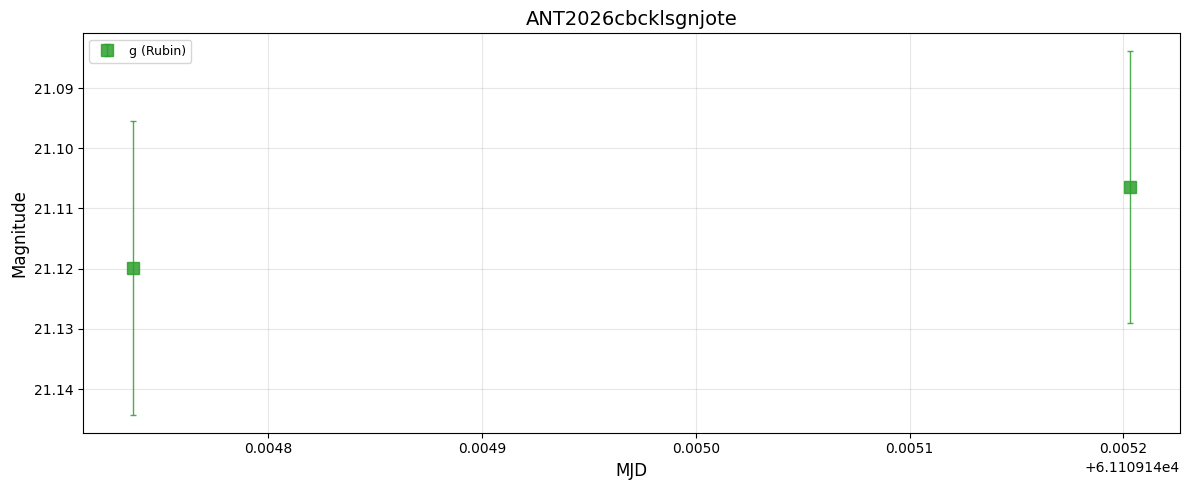

  Stamps: not available



KeyboardInterrupt: Interrupted by user

In [20]:
from IPython.display import clear_output

LABELS = {"s": "SN", "v": "variable", "b": "bogus"}
classifications = {}
class_file = f'classifications_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'

if candidates is None or len(candidates) == 0:
    print("No candidates to classify. Run the pipeline first.")
else:
    total = len(candidates)
    for i, (idx, row) in enumerate(candidates.iterrows()):
        clear_output(wait=True)

        # --- header ---
        tally = {v: list(classifications.values()).count(v) for v in LABELS.values()}
        tally_str = "  ".join(f"{v}={n}" for v, n in tally.items() if n)
        print(
            f"=== Candidate {i+1}/{total} === classified: {len(classifications)}  {tally_str}"
        )
        print()

        # --- IDs ---
        ant_id = row.get("object_id_ANTARES", "")
        alerce_id = row.get("object_id_ALeRCE", "")
        lsst_id = row.get("object_id_ALeRCE-LSST", "")
        rubin_id = row.get("rubin_dia_object_id", "")
        oid = lsst_id or ant_id or alerce_id or "?"
        if str(oid) == "nan":
            oid = ant_id or alerce_id or "?"
        print(f"  Object:    {oid}")
        if rubin_id and str(rubin_id) != "nan":
            print(f"  Rubin DIA: {rubin_id}")
        print(f"  RA, Dec:   {row['ra']:.5f}, {row['dec']:.5f}")
        print(f"  DDF:       {row.get('ddf_field', '?')}")

        prob = row.get("mean_ia_prob")
        print(f"  P(Ia):     {prob:.3f}" if pd.notna(prob) else "  P(Ia):     N/A")
        print(f"  Brokers:   {row.get('brokers_detected', '?')}")

        # Quality diagnostics
        sg = row.get("sgscore_ANTARES")
        dur = row.get("duration_ANTARES")
        rb = row.get("rb_score_ANTARES")
        diag = []
        if pd.notna(sg):
            diag.append(f"SG={sg:.2f}")
        if pd.notna(dur):
            diag.append(f"dur={dur:.0f}d")
        if pd.notna(rb):
            diag.append(f"RB={rb:.2f}")
        if diag:
            print(f"  Quality:   {', '.join(diag)}")

        # ATLAS info
        if row.get("atlas_has_data"):
            print(
                f"  ATLAS:     cyan={row.get('atlas_n_cyan',0)}, orange={row.get('atlas_n_orange',0)}"
            )

        tags = row.get("tags_ANTARES", "")
        if tags and str(tags) != "nan":
            print(f"  Tags:      {tags}")
        print()

        # --- light curve --- prefer ALeRCE-LSST, then ANTARES, then ALeRCE
        broker = None
        obj_id = None
        for bk, bid in [
            ("ALeRCE-LSST", lsst_id),
            ("ANTARES", ant_id),
            ("ALeRCE", alerce_id),
        ]:
            if bid and str(bid) != "nan":
                broker = bk
                obj_id = bid
                break

        if obj_id is None or str(obj_id) == "nan":
            obj_id = ant_id or alerce_id or "?"
            broker = "ANTARES" if ant_id else "ALeRCE"

        try:
            lc = monitor.get_light_curve(obj_id, broker=broker)

            # If primary broker is not ALeRCE-LSST, also try LSST light curve
            if broker != "ALeRCE-LSST" and lsst_id and str(lsst_id) != "nan":
                lsst_lc = monitor.get_light_curve(lsst_id, broker="ALeRCE-LSST")
                if lsst_lc is not None:
                    lc = (
                        pd.concat([lc, lsst_lc], ignore_index=True)
                        if lc is not None
                        else lsst_lc
                    )

            # Also fetch ATLAS light curve
            atlas_lc = None
            if monitor.atlas_client.available:
                atlas_lc = monitor.get_atlas_light_curve(row["ra"], row["dec"])

            if lc is not None and atlas_lc is not None:
                lc = pd.concat([lc, atlas_lc], ignore_index=True)
            elif atlas_lc is not None:
                lc = atlas_lc

            if lc is not None and len(lc) > 0:
                n_pts = len(lc)
                survey_info = ""
                if "survey" in lc.columns:
                    parts = [f"{s}={n}" for s, n in lc["survey"].value_counts().items()]
                    survey_info = "  ".join(parts)
                print(f"  Light curve: {n_pts} pts  {survey_info}")

                lc_prep = PlottingUtils.prepare_light_curve(lc)
                if lc_prep is not None and len(lc_prep) > 0:
                    fig = PlottingUtils.plot_light_curve_matplotlib(
                        lc_prep, title=f"{obj_id}", figsize=(12, 5)
                    )
                    plt.show()
            else:
                print("  Light curve: no data")
        except Exception as e:
            print(f"  Light curve error: {e}")

        # --- stamp info ---
        try:
            stamps = monitor.get_stamps(obj_id, row["ra"], row["dec"], broker=broker)
            if stamps and stamps.get("stamps"):
                print(f"  Stamps: {list(stamps['stamps'].keys())}")
            else:
                print("  Stamps: not available")
        except:
            print("  Stamps: not available")

        print()

        # --- classify ---
        try:
            key = (
                input("  (s)n  (v)ariable  (b)ogus  Enter=skip  q=quit: ")
                .strip()
                .lower()
            )
        except EOFError:
            break

        if key == "q":
            print("Quitting.")
            break
        elif key in LABELS:
            classifications[oid] = LABELS[key]
            # save incrementally
            pd.DataFrame(
                [
                    {"object_id": k, "classification": v}
                    for k, v in classifications.items()
                ]
            ).to_csv(class_file, index=False)

    # --- final summary ---
    clear_output(wait=True)
    tally = {v: list(classifications.values()).count(v) for v in LABELS.values()}
    print(f"Done. Classified {len(classifications)}/{total} candidates.")
    for label, count in tally.items():
        if count:
            print(f"  {label}: {count}")
    if classifications:
        print(f"\nSaved to {class_file}")
    else:
        print("No classifications made.")

## Architecture and Known Limitations

### Code Architecture

```
RubinAlerts/
├── supernova_monitor.py          # Main orchestrator — coordinates broker queries, aggregation, filtering
├── broker_clients/
│   ├── alerce_client.py          # ALeRCE client (ZTF and LSST surveys via survey= parameter)
│   ├── alerce_db_client.py       # ALeRCE direct PostgreSQL client (bulk queries, SPM features)
│   └── antares_client.py         # ANTARES client (ZTF + limited Rubin data)
├── core/
│   ├── alert_aggregator.py       # Cross-match, deduplicate, merge broker results + extinction
│   ├── ddf_fields.py             # DDF field definitions (coordinates, search radii)
│   ├── magellan_planning.py      # Merit scoring, observability, Magellan catalog generation
│   └── peak_fitting.py           # Parabola + Villar SPM peak fitting, SALT2 template fitting
├── host_galaxy/
│   └── morphology_filter.py      # Elliptical/spiral host classification from SDSS/PS1 colors
├── cache/
│   └── alert_cache.py            # SQLite-backed caching (alerts, extinction, NED, galaxy info)
├── utils/
│   ├── coordinates.py            # Coordinate utilities (separation calculations, field matching)
│   ├── extinction.py             # Galactic dust extinction via IRSA SFD maps
│   ├── ned_query.py              # NED spectroscopic redshift lookups
│   ├── catalog_query.py          # SDSS/Pan-STARRS catalog queries for host galaxy properties
│   └── plotting.py               # Light curve plotting (matplotlib + plotly)
├── notebooks/
│   ├── supernova_monitor.ipynb   # This notebook — operational pipeline
│   └── test_new_features.ipynb   # Feature validation and diagnostic plots
└── docs/                         # LaTeX documentation
```

### Pipeline Flow

```
Step 1: Query brokers (ANTARES, ALeRCE-ZTF, ALeRCE-LSST)
Step 2: Merge & deduplicate across brokers (1 arcsec matching)
   └── Apply galactic extinction corrections (IRSA SFD)
Step 3: Screen against known variable star catalogs
Step 4: Filter by P(Ia) threshold, broker agreement, broker count
Step 5: NED spectroscopic redshift lookups for host galaxies
Step 6: [Optional] Elliptical host galaxy filter (SDSS/PS1 colors)
Step 7: [Optional] ATLAS forced photometry enrichment
Step 8: Peak fitting (parabola in flux space, Villar SPM from ALeRCE DB)
   └── Extinction-corrected peak magnitudes
Step 9: Merit scoring for Magellan spectroscopic follow-up
   └── Absolute magnitude estimation from peak_mag_corrected - distmod
```

### Known Limitations

1. **ALeRCE-LSST cone search is broken.** The ALeRCE API does not correctly handle `ra/dec/radius` parameters for LSST survey queries (returns empty results). The workaround is to query globally for all SN-classified objects and filter locally by DDF coordinates.

2. **LSST stamp classifier does not sub-classify SN types.** The `stamp_classifier_rubin` outputs P(SN) / P(AGN) / P(VS) / P(asteroid) / P(bogus). A high P(SN) means "likely supernova" but does not distinguish Type Ia from other SN types.

3. **ANTARES P(Ia) is a heuristic proxy, not ML.** Capped at 0.50 by design so ANTARES-only detections cannot dominate the ranking.

4. **Host galaxy morphology from PS1/SDSS only works for ~3 of 7 DDFs.** PS1 coverage ends at dec ~ -30 and SDSS has limited southern sky coverage. The southern DDFs (ECDFS, ELAIS-S1, EDFS) will need Rubin photometry or DES/SkyMapper catalogs for host classification.

5. **NED redshift completeness is limited.** NED spectroscopic redshifts are only available for ~50% of candidates (depends on host galaxy brightness and prior spectroscopic surveys). Missing redshifts do not block pipeline operation — candidates proceed without absolute magnitude estimates.

6. **Extinction corrections are per-object, not per-field.** Each candidate is queried at its own RA/Dec against the SFD dust maps (~6 arcmin resolution). Values are cached in SQLite to avoid redundant IRSA queries.

7. **ALeRCE ZTF database is read-only and may lag.** The direct PostgreSQL connection to ALeRCE's ZTF DB provides fast bulk queries but data may be hours to days behind the REST API. The pipeline falls back to the REST API if DB connection fails.


## Advanced: ALeRCE TAP Queries

The ALeRCE TAP (Table Access Protocol) service provides SQL-like access via ADQL (Astronomical Data Query Language) to the full ALeRCE database, including tables not accessible through the Python client. This is useful for:

- **Bulk queries** — e.g., "all SN-classified objects with >50 detections in the last 30 days"
- **Cross-table joins** — e.g., joining detections with the diaObject table for per-band flux statistics
- **Solar system objects** — ssObject queries (not available via the Python client)
- **Custom filtering** — any ADQL WHERE clause

The TAP endpoint is `https://tap.alerce.online/tap`. It requires the `pyvo` package (`pip install pyvo`).

### Key Tables

| Table                    | Description                                                                               |
| ------------------------ | ----------------------------------------------------------------------------------------- |
| `object`                 | One row per object: mean RA/Dec, first/last MJD, n_det, n_forced                          |
| `detection`              | Per-epoch detections (common columns across surveys)                                      |
| `lsst_detection`         | LSST-specific detection columns (psfFlux, scienceFlux, pixel flags, shape, trail, dipole) |
| `forced_photometry`      | Forced photometry epochs (common columns)                                                 |
| `lsst_forced_photometry` | LSST-specific forced photometry columns                                                   |
| `lsst_dia_object`        | Latest diaObject record: per-band flux stats (mean, min, max, slope)                      |
| `probability`            | Classification probabilities per object per classifier                                    |
| `taxonomy`               | Class names for each classifier (SN=0, AGN=1, VS=2, asteroid=3, bogus=4)                  |
| `band`                   | Band name mapping (1=g, 2=r, 3=i, 4=z, 5=y, 6=u for LSST)                                 |

### Identifiers

- **`tid = 1`** — Rubin/LSST telescope
- **`sid = 1`** — diaObject (non-moving); **`sid = 2`** — ssObject (moving)
- **`oid`** — For `sid=1`, this is the `diaObjectId` from Rubin
- **`measurement_id`** — `diaSourceId` (detections) or `diaForcedSourceId` (forced photometry)

For detailed table schemas and more examples, see the reference notebooks in `usecases/notebooks/LSST/`.


In [21]:
# Example TAP query: top 15 SN candidates with >50 detections, recent activity
# (Based on usecases/notebooks/LSST/ALeRCE_LSST_TAP_Queries.ipynb)

import pyvo as vo
from astropy.time import Time

alerce_tap = vo.dal.TAPService("https://tap.alerce.online/tap")

# Find SN-classified objects with many detections and recent last observation
firstmjd_min = Time("2025-11-01T00:00:00", format="isot", scale="utc").mjd
lastmjd_min = Time("2026-02-01T00:00:00", format="isot", scale="utc").mjd

query = f"""
SELECT
    o.oid, o.meanra, o.meandec, o.firstmjd, o.lastmjd,
    o.deltamjd, o.n_det, o.n_forced,
    p.probability, p.ranking
FROM
    alerce_tap.object AS o
JOIN
    alerce_tap.probability AS p
ON
    o.oid = p.oid AND o.sid = p.sid
WHERE
    o.tid = 1
    AND o.sid = 1
    AND p.classifier_id = 1
    AND p.class_id = 0
    AND p.ranking = 1
    AND o.n_det >= 50
    AND o.firstmjd >= {firstmjd_min}
    AND o.lastmjd >= {lastmjd_min}
ORDER BY
    p.probability DESC
"""

print("Running TAP query...")
result = alerce_tap.search(query).to_table().to_pandas()
print(f"Found {len(result)} objects\n")

if len(result) > 0:
    # Add Explorer links
    result["explorer_link"] = result["oid"].apply(
        lambda x: f"https://lsst.alerce.online/object/{x}?survey=lsst"
    )
    display(result.head(20))
else:
    print("No results")

Running TAP query...
Found 170 objects



,oid,meanra,meandec,firstmjd,lastmjd,deltamjd,n_det,n_forced,probability,ranking,explorer_link
0,313893023122980956,62.081009,-46.931759,61033.284793,61095.094861,61.810069,150,184,0.995795,1,https://lsst.alerce.online/object/313893023122...
1,170028526873870371,186.808234,8.482416,61090.249392,61098.241373,7.991980,457,464,0.995368,1,https://lsst.alerce.online/object/170028526873...
2,313897384094990464,62.579228,-47.370058,61034.161767,61095.094861,60.933095,98,181,0.994967,1,https://lsst.alerce.online/object/313897384094...
3,170032925073997933,186.699774,7.671551,61090.267104,61095.218546,4.951442,99,172,0.994210,1,https://lsst.alerce.online/object/170032925073...
4,170019696272736349,61.497111,-49.245787,61088.098045,61101.030547,12.932502,454,492,0.993127,1,https://lsst.alerce.online/object/170019696272...
5,170028526740701203,186.910111,8.014844,61090.248460,61098.241373,7.992913,387,570,0.992937,1,https://lsst.alerce.online/object/170028526740...
6,170028526579744777,185.020121,7.815352,61090.248460,61098.232175,7.983715,391,509,0.992041,1,https://lsst.alerce.online/object/170028526579...
7,170028526652096607,187.270931,7.253687,61090.248460,61098.210024,7.961564,110,509,0.991492,1,https://lsst.alerce.online/object/170028526652...
8,170028527303262373,187.404372,7.932739,61090.250794,61095.217021,4.966226,63,196,0.990184,1,https://lsst.alerce.online/object/170028527303...
9,170028485948473400,64.230276,-47.771431,61090.048455,61095.089601,5.041146,66,167,0.990077,1,https://lsst.alerce.online/object/170028485948...
